c:\Users\pande\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


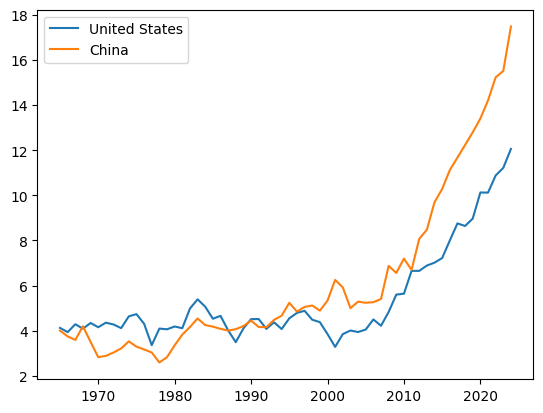

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels
from prophet import Prophet
#'pd' for example is a library naming convention

df = pd.read_csv("owid-energy-data.csv")
#pd.read_csv ALWAYS returns a dataframe
#if you want to check type: print(type(df))
#pd.read_csv tells pandas to open and read the file 
#it's a method/function that is within pandas
#object.method(inputs)


#print(df.head())
#dataframe itself is an object with builtin functions
#df.head() are the first 5 ROWS of dataframe
#the header row is not included in the 5

#arrow -> means the TYPE the fn returns
#default for df.head is 5 rows

#STEP 2: filter the data
countries = ["United States", "China"]

#dataframe is indexable by row position AND column string
#first: index by column name
countries_column = df["country"] #TYPE: SERIES
boolean_series = countries_column.isin(countries) #TYPE: SERIES 
#isin method loops over every entry in the column and checks against countries list

#print(type(countries_column))
#print(type(row_indices))

#second: index by rows
filtered_df = df[boolean_series]
#filtered dataframe includes all the rows whose country column is US or China
#all columns are kept, only rows are filtered

#SUMMARY: 
    #filtering rows: index df using a boolean series df[df["column"].isin(columnlist)]
    #filtering columns: pass in list of column names df[['x', 'y']]
    
#print(filtered_df)

#make plot of total energy usage over time
#make plot of energy share over time

#make plot of renewable share energy over time:
#further filtering columns to include only share of energy over time for diff. sources
#how can we ensure there is no overlap?
renewables_share = filtered_df[["country", "year","renewables_share_energy"]]
#important: columns excluded because they are sumer: 
#  fossil(coal,oil,gas),renewable(solar,wind,hydro,other),low carbon(renew,nuclear)


#filter by rows
us_bool = renewables_share["country"].isin(["United States"])
us_df = renewables_share[us_bool]

china_bool = renewables_share["country"].isin(["China"])
china_df = renewables_share[china_bool]

plt.plot(us_df["year"], 
us_df["renewables_share_energy"], 
label="United States")  
    
plt.plot(china_df["year"], 
china_df["renewables_share_energy"],
label="China")

plt.legend()
plt.savefig("renewables_share_energy.png")
plt.show() #both datasets on one graph

#to embed image: ![title](file_name)
#IMPORTANT: must save fig before showing
#showing visualizes and then clears

#graph observations:
##end of code, moved to interactive pythong jupyter notebook

**Initial Observations of renewables share of total energy consumption over time**
- renewables energy share for both countries grew from about 4% to about 12% for the US and 18% for China
- China's renewables share started as (on average) less than that of the United States' share until around 1990 when China's share began to grow while the United States' remained stagnant
- The United states' share started to grow in 2005 - 15 years after China's
- the rate of growth seems to be greater for China

NOTE: renewables include solar, wind, hydro, nuclear, and other sources

**Historical Context**

**<u>Next Step: Decomposition</u>** (Trend, Seasonality, Residual)